# 차원 축소 알고리즘 실무 실습 노트북

이 노트북은 다음 순서로 차원 축소를 실습합니다.

1. PCA로 기본 차원 축소 실습
2. LDA로 라벨 기반 차원 축소 실습
3. t-SNE 또는 UMAP으로 2차원 시각화
4. Autoencoder로 딥러닝 기반 차원 축소 실습

사용 데이터셋은 `sklearn.datasets.load_digits()`입니다. 각 이미지는 8x8 픽셀이므로 원본 입력 차원은 64차원입니다.

## 1. 라이브러리 설치 및 불러오기

Google Colab 기준으로 실행할 수 있도록 UMAP 설치 코드를 포함합니다.

In [1]:
# ============================================================
# 1. 필요한 라이브러리 설치
# ============================================================

# UMAP 알고리즘을 사용하기 위한 외부 라이브러리입니다.
# Colab에서 처음 실행할 경우 설치가 필요합니다.
!pip -q install umap-learn

# ============================================================
# 2. 기본 라이브러리 불러오기
# ============================================================

# numpy는 배열, 행렬, 수치 계산에 사용하는 라이브러리입니다.
import numpy as np

# pandas는 표 형태의 데이터를 다룰 때 사용하는 라이브러리입니다.
import pandas as pd

# matplotlib은 그래프를 그릴 때 사용하는 라이브러리입니다.
import matplotlib.pyplot as plt

# ============================================================
# 3. 머신러닝 관련 라이브러리 불러오기
# ============================================================

# 손글씨 숫자 데이터셋을 불러옵니다.
from sklearn.datasets import load_digits

# 학습 데이터와 테스트 데이터를 나눕니다.
from sklearn.model_selection import train_test_split

# 데이터 표준화를 수행합니다.
from sklearn.preprocessing import StandardScaler

# PCA 차원 축소 알고리즘입니다.
from sklearn.decomposition import PCA

# LDA 차원 축소 알고리즘입니다.
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# t-SNE 차원 축소 알고리즘입니다.
from sklearn.manifold import TSNE

# 분류 성능 비교를 위한 기본 분류 모델입니다.
from sklearn.linear_model import LogisticRegression

# 정확도, 분류 리포트 평가 함수입니다.
from sklearn.metrics import accuracy_score, classification_report

# UMAP 알고리즘입니다.
import umap

# ============================================================
# 4. PyTorch 관련 라이브러리 불러오기
# ============================================================

# PyTorch 핵심 라이브러리입니다.
import torch

# 신경망 계층과 손실 함수를 제공합니다.
import torch.nn as nn

# Adam 같은 최적화 알고리즘을 제공합니다.
import torch.optim as optim

# TensorDataset은 입력과 정답 데이터를 묶고,
# DataLoader는 batch 단위로 데이터를 공급합니다.
from torch.utils.data import TensorDataset, DataLoader

# ============================================================
# 5. 랜덤 시드 고정
# ============================================================

# 매번 실행할 때 가능한 동일한 결과가 나오도록 설정합니다.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# GPU가 있으면 GPU용 랜덤 시드도 고정합니다.
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("라이브러리 준비 완료")
print("PyTorch version:", torch.__version__)
print("GPU 사용 가능 여부:", torch.cuda.is_available())

라이브러리 준비 완료
PyTorch version: 2.11.0+cu128
GPU 사용 가능 여부: True


## 2. 데이터셋 로드 및 구조 확인

`digits` 데이터셋은 0~9 손글씨 숫자 이미지입니다. 각 이미지는 8x8 픽셀이고, 머신러닝 입력으로는 64개의 숫자 특성으로 표현됩니다.

In [2]:
# ============================================================
# 손글씨 숫자 데이터셋 불러오기
# ============================================================

# load_digits()는 sklearn에서 제공하는 내장 데이터셋입니다.
digits = load_digits()

# X는 입력 데이터입니다.
# shape은 (샘플 수, 특성 수) 형태입니다.
X = digits.data

# y는 정답 라벨입니다.
# 각 이미지가 어떤 숫자인지 0~9 값으로 저장되어 있습니다.
y = digits.target

target_names = digits.target_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("클래스 목록:", target_names)

# DataFrame으로 변환하여 데이터 구조를 확인합니다.
df = pd.DataFrame(X, columns=[f"pixel_{i}" for i in range(X.shape[1])])
df["target"] = y

df.head()

X shape: (1797, 64)
y shape: (1797,)
클래스 목록: [0 1 2 3 4 5 6 7 8 9]


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


## 3. 원본 이미지 시각화

차원 축소 전, 원본 데이터가 어떤 이미지인지 확인합니다.

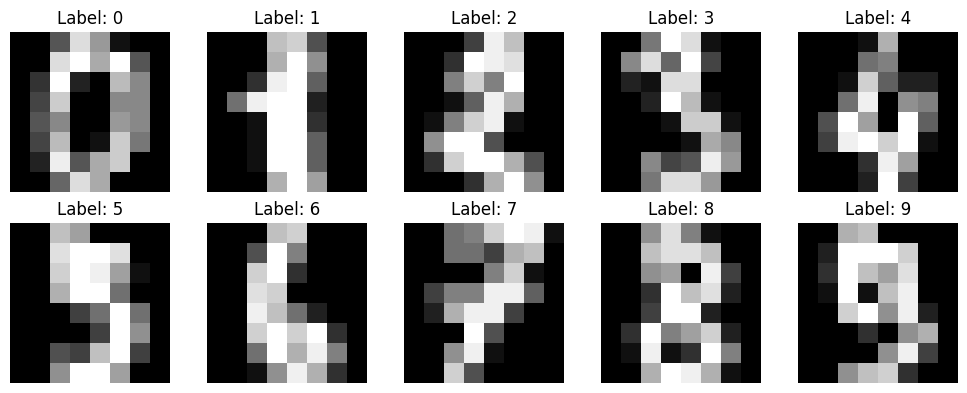

In [3]:
# ============================================================
# 원본 손글씨 이미지 확인
# ============================================================

plt.figure(figsize=(10, 4))

# 앞에서부터 10개의 이미지를 출력합니다.
for i in range(10):
    plt.subplot(2, 5, i + 1)

    # digits.images[i]는 8x8 이미지 형태입니다.
    plt.imshow(digits.images[i], cmap="gray")

    # 제목에 실제 정답 숫자를 표시합니다.
    plt.title(f"Label: {y[i]}")

    # 이미지 확인에는 축 눈금이 필요 없으므로 제거합니다.
    plt.axis("off")

plt.tight_layout()
plt.show()

## 4. 학습 데이터와 테스트 데이터 분리

분류 성능 비교를 위해 데이터를 학습용과 테스트용으로 나눕니다.

In [4]:
# ============================================================
# 학습 데이터와 테스트 데이터 분리
# ============================================================

# test_size=0.2는 전체 데이터의 20%를 테스트 데이터로 사용한다는 의미입니다.
# stratify=y는 각 숫자 클래스 비율을 학습/테스트 데이터에 비슷하게 유지합니다.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1437, 64)
X_test shape: (360, 64)
y_train shape: (1437,)
y_test shape: (360,)


## 5. 데이터 표준화

PCA, LDA, Logistic Regression은 특성 스케일의 영향을 받을 수 있으므로 평균 0, 표준편차 1이 되도록 표준화합니다.

중요: 학습 데이터에는 `fit_transform()`, 테스트 데이터에는 `transform()`만 사용합니다.

In [5]:
# ============================================================
# 데이터 표준화
# ============================================================

# StandardScaler는 각 컬럼의 평균을 0, 표준편차를 1로 변환합니다.
scaler = StandardScaler()

# 학습 데이터에서 평균과 표준편차를 계산하고 변환합니다.
X_train_scaled = scaler.fit_transform(X_train)

# 테스트 데이터는 학습 데이터 기준 평균/표준편차로만 변환합니다.
X_test_scaled = scaler.transform(X_test)

print("표준화 전 평균:", round(X_train.mean(), 4))
print("표준화 후 평균:", round(X_train_scaled.mean(), 4))
print("표준화 후 표준편차:", round(X_train_scaled.std(), 4))

표준화 전 평균: 4.8951
표준화 후 평균: 0.0
표준화 후 표준편차: 0.9763


## 6. 기준 모델 성능 확인

차원 축소 전 64차원 원본 데이터로 Logistic Regression을 학습하여 기준 정확도를 확인합니다.

In [6]:
# ============================================================
# 원본 64차원 데이터로 기준 모델 학습
# ============================================================

baseline_model = LogisticRegression(
    max_iter=2000,
    random_state=SEED
)

# 표준화된 원본 학습 데이터로 모델 학습
baseline_model.fit(X_train_scaled, y_train)

# 표준화된 원본 테스트 데이터로 예측
baseline_pred = baseline_model.predict(X_test_scaled)

# 정확도 계산
baseline_acc = accuracy_score(y_test, baseline_pred)

print("원본 64차원 기준 정확도:", round(baseline_acc, 4))
print(classification_report(y_test, baseline_pred))

원본 64차원 기준 정확도: 0.9722
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.89      0.89      0.89        36
           2       1.00      1.00      1.00        35
           3       0.97      1.00      0.99        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        36
           8       0.89      0.89      0.89        35
           9       1.00      0.97      0.99        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



# Part 1. PCA로 기본 차원 축소 실습

PCA는 정답 라벨을 사용하지 않는 비지도학습 기반 차원 축소 알고리즘입니다. 데이터의 분산이 큰 방향을 찾아 새로운 축을 만들고, 그 축으로 데이터를 변환합니다.

In [7]:
# ============================================================
# PCA 2차원 축소
# ============================================================

# n_components=2는 64차원 데이터를 2차원으로 줄인다는 의미입니다.
pca_2d = PCA(n_components=2, random_state=SEED)

# 학습 데이터로 PCA 축을 찾고 변환합니다.
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)

# 테스트 데이터는 학습된 PCA 축으로만 변환합니다.
X_test_pca_2d = pca_2d.transform(X_test_scaled)

print("PCA 적용 전:", X_train_scaled.shape)
print("PCA 적용 후:", X_train_pca_2d.shape)
print("PC1 설명 분산 비율:", round(pca_2d.explained_variance_ratio_[0], 4))
print("PC2 설명 분산 비율:", round(pca_2d.explained_variance_ratio_[1], 4))
print("누적 설명 분산 비율:", round(pca_2d.explained_variance_ratio_.sum(), 4))

PCA 적용 전: (1437, 64)
PCA 적용 후: (1437, 2)
PC1 설명 분산 비율: 0.1204
PC2 설명 분산 비율: 0.0966
누적 설명 분산 비율: 0.217


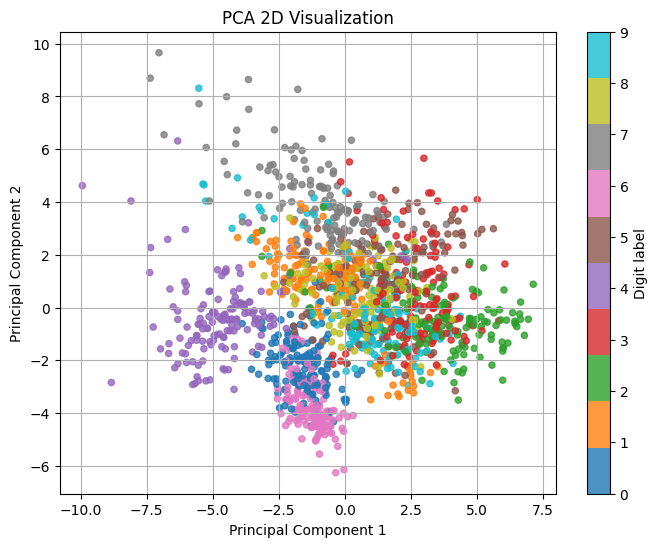

In [8]:
# ============================================================
# PCA 2차원 결과 시각화
# ============================================================

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_train_pca_2d[:, 0],
    X_train_pca_2d[:, 1],
    c=y_train,
    cmap="tab10",
    s=20,
    alpha=0.8
)

plt.colorbar(scatter, label="Digit label")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA 2D Visualization")
plt.grid(True)
plt.show()

## PCA 20차원 축소 후 분류 성능 확인

2차원 PCA는 시각화에는 좋지만 정보 손실이 큽니다. 실무에서는 모델 입력용으로 10차원, 20차원, 30차원처럼 더 많은 주성분을 사용합니다.

In [9]:
# ============================================================
# PCA 20차원 축소
# ============================================================

pca_20 = PCA(n_components=20, random_state=SEED)

X_train_pca_20 = pca_20.fit_transform(X_train_scaled)
X_test_pca_20 = pca_20.transform(X_test_scaled)

print("PCA 20차원 적용 전:", X_train_scaled.shape)
print("PCA 20차원 적용 후:", X_train_pca_20.shape)
print("누적 설명 분산 비율:", round(pca_20.explained_variance_ratio_.sum(), 4))

PCA 20차원 적용 전: (1437, 64)
PCA 20차원 적용 후: (1437, 20)
누적 설명 분산 비율: 0.7899


In [10]:
# ============================================================
# PCA 20차원 데이터로 분류 모델 학습
# ============================================================

pca_model = LogisticRegression(
    max_iter=2000,
    random_state=SEED
)

pca_model.fit(X_train_pca_20, y_train)
pca_pred = pca_model.predict(X_test_pca_20)
pca_acc = accuracy_score(y_test, pca_pred)

print("원본 64차원 기준 정확도:", round(baseline_acc, 4))
print("PCA 20차원 기준 정확도:", round(pca_acc, 4))
print(classification_report(y_test, pca_pred))

원본 64차원 기준 정확도: 0.9722
PCA 20차원 기준 정확도: 0.9417
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.85      0.81      0.83        36
           2       0.95      1.00      0.97        35
           3       1.00      0.95      0.97        37
           4       0.88      1.00      0.94        36
           5       0.97      0.97      0.97        37
           6       0.95      0.97      0.96        36
           7       1.00      0.97      0.99        36
           8       0.91      0.86      0.88        35
           9       0.92      0.92      0.92        36

    accuracy                           0.94       360
   macro avg       0.94      0.94      0.94       360
weighted avg       0.94      0.94      0.94       360



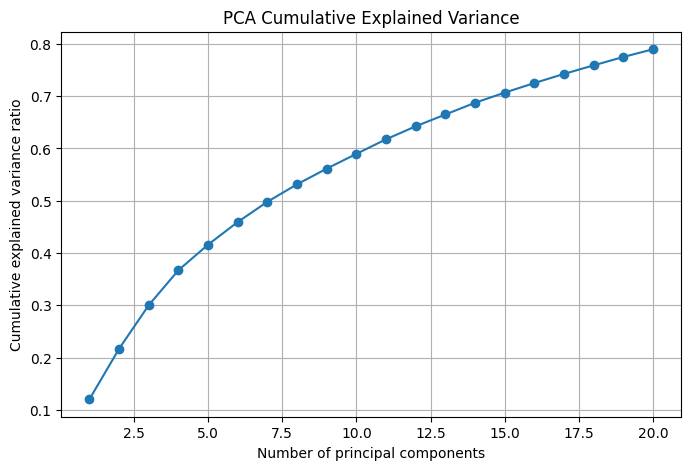

In [11]:
# ============================================================
# PCA 누적 설명 분산 비율 그래프
# ============================================================

cumulative_variance = np.cumsum(pca_20.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance ratio")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True)
plt.show()

# Part 2. LDA로 라벨 기반 차원 축소 실습

LDA는 정답 라벨을 사용하는 지도학습 기반 차원 축소입니다. PCA가 분산이 큰 방향을 찾는다면, LDA는 클래스가 잘 구분되는 방향을 찾습니다.

In [12]:
# ============================================================
# LDA 2차원 축소
# ============================================================

# LDA는 정답 라벨을 사용하므로 fit_transform에 y_train도 입력합니다.
lda_2d = LinearDiscriminantAnalysis(n_components=2)

X_train_lda_2d = lda_2d.fit_transform(X_train_scaled, y_train)
X_test_lda_2d = lda_2d.transform(X_test_scaled)

print("LDA 적용 전:", X_train_scaled.shape)
print("LDA 적용 후:", X_train_lda_2d.shape)

LDA 적용 전: (1437, 64)
LDA 적용 후: (1437, 2)


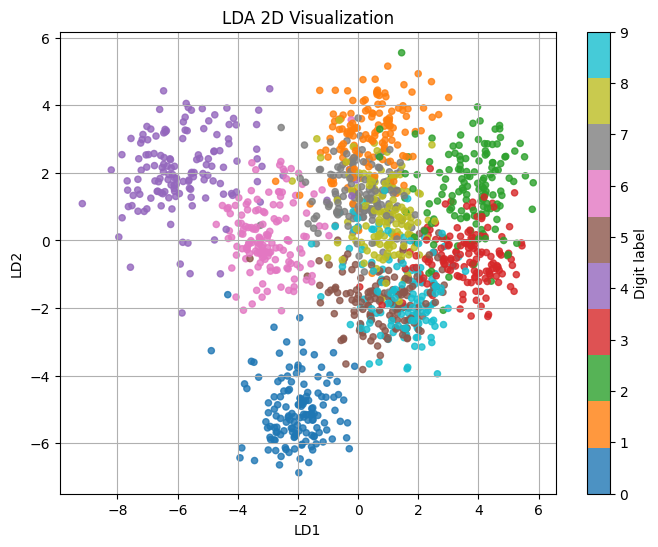

In [13]:
# ============================================================
# LDA 2차원 결과 시각화
# ============================================================

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_train_lda_2d[:, 0],
    X_train_lda_2d[:, 1],
    c=y_train,
    cmap="tab10",
    s=20,
    alpha=0.8
)

plt.colorbar(scatter, label="Digit label")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA 2D Visualization")
plt.grid(True)
plt.show()

## LDA 최대 차원

LDA가 만들 수 있는 최대 차원은 `min(특성 수, 클래스 수 - 1)`입니다. digits 데이터셋은 클래스가 10개이므로 최대 9차원까지 만들 수 있습니다.

In [14]:
# ============================================================
# LDA 9차원 축소 후 분류 성능 확인
# ============================================================

lda_9 = LinearDiscriminantAnalysis(n_components=9)

X_train_lda_9 = lda_9.fit_transform(X_train_scaled, y_train)
X_test_lda_9 = lda_9.transform(X_test_scaled)

lda_model = LogisticRegression(
    max_iter=2000,
    random_state=SEED
)

lda_model.fit(X_train_lda_9, y_train)
lda_pred = lda_model.predict(X_test_lda_9)
lda_acc = accuracy_score(y_test, lda_pred)

print("원본 64차원 기준 정확도:", round(baseline_acc, 4))
print("PCA 20차원 기준 정확도:", round(pca_acc, 4))
print("LDA 9차원 기준 정확도:", round(lda_acc, 4))
print(classification_report(y_test, lda_pred))

원본 64차원 기준 정확도: 0.9722
PCA 20차원 기준 정확도: 0.9417
LDA 9차원 기준 정확도: 0.9556
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.89      0.89      0.89        36
           2       1.00      0.94      0.97        35
           3       0.97      0.97      0.97        37
           4       0.90      1.00      0.95        36
           5       0.97      1.00      0.99        37
           6       0.95      0.97      0.96        36
           7       0.97      0.94      0.96        36
           8       0.97      0.89      0.93        35
           9       0.95      0.97      0.96        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



# Part 3. t-SNE 또는 UMAP으로 2차원 시각화

t-SNE와 UMAP은 주로 고차원 데이터의 군집 구조를 2차원으로 확인할 때 사용합니다. 두 방법 모두 비선형 차원 축소 알고리즘입니다.

In [15]:
# ============================================================
# t-SNE 2차원 시각화
# ============================================================

# 시각화 목적이므로 전체 데이터를 표준화해서 사용합니다.
X_scaled_all = scaler.fit_transform(X)

# t-SNE는 transform 기능이 일반적이지 않으므로 주로 전체 데이터 시각화에 사용합니다.
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=SEED
)

X_tsne = tsne.fit_transform(X_scaled_all)

print("t-SNE 적용 전:", X_scaled_all.shape)
print("t-SNE 적용 후:", X_tsne.shape)

t-SNE 적용 전: (1797, 64)
t-SNE 적용 후: (1797, 2)


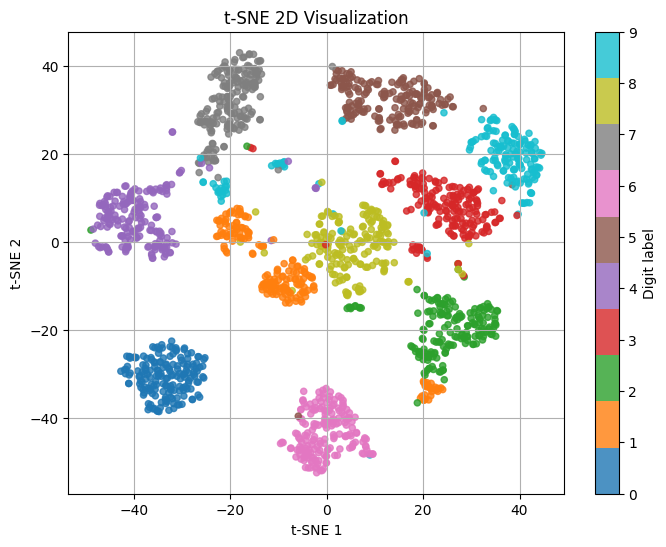

In [16]:
# ============================================================
# t-SNE 결과 시각화
# ============================================================

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap="tab10",
    s=20,
    alpha=0.8
)

plt.colorbar(scatter, label="Digit label")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE 2D Visualization")
plt.grid(True)
plt.show()

In [17]:
# ============================================================
# UMAP 2차원 시각화
# ============================================================

# n_neighbors는 주변 이웃을 몇 개 고려할지 설정합니다.
# min_dist는 저차원 공간에서 점들이 얼마나 가까워질 수 있는지 조절합니다.
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=SEED
)

X_umap = umap_model.fit_transform(X_scaled_all)

print("UMAP 적용 전:", X_scaled_all.shape)
print("UMAP 적용 후:", X_umap.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 적용 전: (1797, 64)
UMAP 적용 후: (1797, 2)


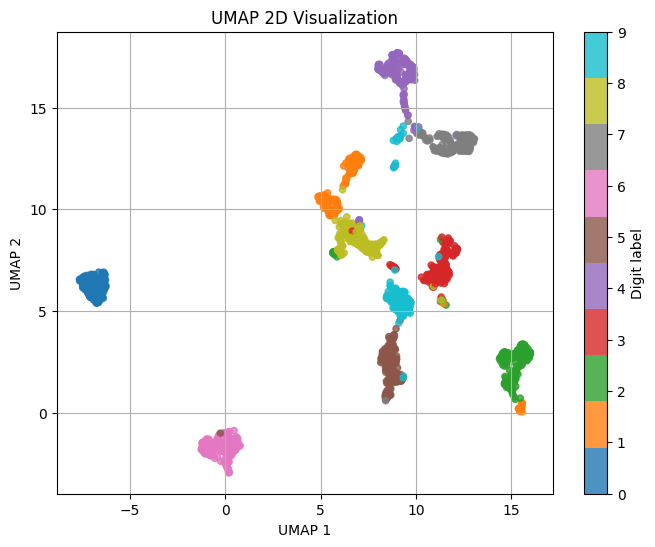

In [18]:
# ============================================================
# UMAP 결과 시각화
# ============================================================

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=y,
    cmap="tab10",
    s=20,
    alpha=0.8
)

plt.colorbar(scatter, label="Digit label")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP 2D Visualization")
plt.grid(True)
plt.show()

# Part 4. Autoencoder로 딥러닝 기반 차원 축소 실습

Autoencoder는 입력 데이터를 압축한 뒤 다시 복원하도록 학습하는 신경망입니다. 중간의 잠재 벡터가 차원 축소된 표현입니다.

In [19]:
# ============================================================
# Autoencoder 학습 데이터 준비
# ============================================================

# digits 픽셀 값은 0~16 범위입니다.
# Sigmoid 출력과 맞추기 위해 0~1 범위로 정규화합니다.
X_ae = X / 16.0

X_train_ae, X_test_ae, y_train_ae, y_test_ae = train_test_split(
    X_ae,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

# numpy 배열을 PyTorch Tensor로 변환합니다.
X_train_tensor = torch.tensor(X_train_ae, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_ae, dtype=torch.float32)

# Autoencoder는 입력 자체를 복원하므로 입력과 정답 모두 X입니다.
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
test_dataset = TensorDataset(X_test_tensor, X_test_tensor)

# batch_size=64는 한 번에 64개씩 학습한다는 의미입니다.
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Autoencoder 학습 데이터:", X_train_tensor.shape)
print("Autoencoder 테스트 데이터:", X_test_tensor.shape)

Autoencoder 학습 데이터: torch.Size([1437, 64])
Autoencoder 테스트 데이터: torch.Size([360, 64])


In [20]:
# ============================================================
# Autoencoder 모델 정의
# ============================================================

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder: 64차원 입력을 2차원 잠재 벡터로 압축합니다.
        self.encoder = nn.Sequential(
            nn.Linear(64, 32),   # 64차원 → 32차원
            nn.ReLU(),           # 비선형 활성화 함수
            nn.Linear(32, 16),   # 32차원 → 16차원
            nn.ReLU(),
            nn.Linear(16, 2)     # 16차원 → 2차원 잠재 벡터
        )

        # Decoder: 2차원 잠재 벡터를 다시 64차원으로 복원합니다.
        self.decoder = nn.Sequential(
            nn.Linear(2, 16),    # 2차원 → 16차원
            nn.ReLU(),
            nn.Linear(16, 32),   # 16차원 → 32차원
            nn.ReLU(),
            nn.Linear(32, 64),   # 32차원 → 64차원
            nn.Sigmoid()         # 출력값을 0~1 범위로 제한
        )

    def forward(self, x):
        # 입력 데이터를 Encoder로 압축합니다.
        z = self.encoder(x)

        # 압축된 z를 Decoder로 복원합니다.
        reconstructed = self.decoder(z)

        return reconstructed, z

# GPU가 가능하면 GPU, 아니면 CPU를 사용합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ae_model = Autoencoder().to(device)

print(ae_model)
print("사용 장치:", device)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=64, bias=True)
    (5): Sigmoid()
  )
)
사용 장치: cuda


In [21]:
# ============================================================
# Autoencoder 학습 설정
# ============================================================

# MSELoss는 원본 입력과 복원 출력의 차이를 계산합니다.
criterion = nn.MSELoss()

# Adam은 딥러닝에서 많이 사용하는 최적화 알고리즘입니다.
optimizer = optim.Adam(ae_model.parameters(), lr=0.001)

# 전체 학습 반복 횟수입니다.
epochs = 100

train_losses = []
test_losses = []

print("학습 설정 완료")

학습 설정 완료


In [22]:
# ============================================================
# Autoencoder 학습 루프
# ============================================================

for epoch in range(epochs):
    # 모델을 학습 모드로 전환합니다.
    ae_model.train()
    train_loss_sum = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        # 이전 gradient를 초기화합니다.
        optimizer.zero_grad()

        # 복원 결과와 잠재 벡터를 얻습니다.
        reconstructed, z = ae_model(batch_X)

        # 복원 결과와 원본 데이터의 차이를 손실로 계산합니다.
        loss = criterion(reconstructed, batch_y)

        # 역전파로 gradient를 계산합니다.
        loss.backward()

        # 파라미터를 업데이트합니다.
        optimizer.step()

        train_loss_sum += loss.item()

    train_loss_avg = train_loss_sum / len(train_loader)

    # 모델을 평가 모드로 전환합니다.
    ae_model.eval()
    test_loss_sum = 0.0

    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            reconstructed, z = ae_model(batch_X)
            loss = criterion(reconstructed, batch_y)
            test_loss_sum += loss.item()

    test_loss_avg = test_loss_sum / len(test_loader)

    train_losses.append(train_loss_avg)
    test_losses.append(test_loss_avg)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss_avg:.6f} Test Loss: {test_loss_avg:.6f}")

Epoch [10/100] Train Loss: 0.072184 Test Loss: 0.072589
Epoch [20/100] Train Loss: 0.059965 Test Loss: 0.060416
Epoch [30/100] Train Loss: 0.052591 Test Loss: 0.053219
Epoch [40/100] Train Loss: 0.049528 Test Loss: 0.050149
Epoch [50/100] Train Loss: 0.047826 Test Loss: 0.048914
Epoch [60/100] Train Loss: 0.045974 Test Loss: 0.047189
Epoch [70/100] Train Loss: 0.044751 Test Loss: 0.046039
Epoch [80/100] Train Loss: 0.043444 Test Loss: 0.045046
Epoch [90/100] Train Loss: 0.042197 Test Loss: 0.044150
Epoch [100/100] Train Loss: 0.041175 Test Loss: 0.043309


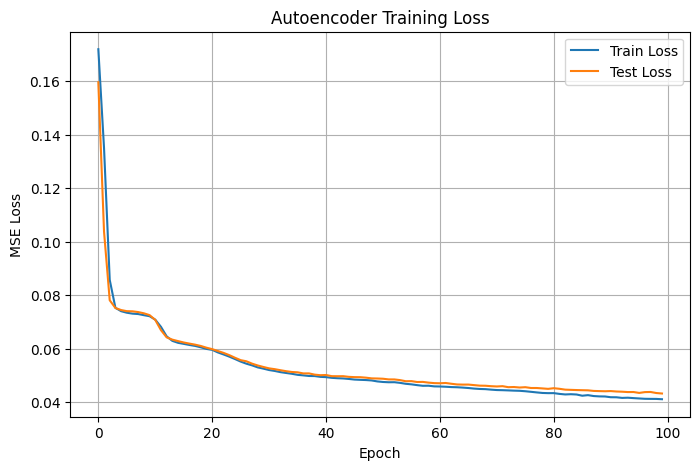

In [23]:
# ============================================================
# Autoencoder 손실 그래프
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
# ============================================================
# Autoencoder 2차원 잠재 벡터 추출
# ============================================================

X_all_tensor = torch.tensor(X_ae, dtype=torch.float32).to(device)

ae_model.eval()
with torch.no_grad():
    reconstructed_all, latent_all = ae_model(X_all_tensor)

# Tensor를 numpy 배열로 변환합니다.
X_autoencoder_2d = latent_all.cpu().numpy()

print("Autoencoder 적용 전:", X_ae.shape)
print("Autoencoder 잠재 벡터:", X_autoencoder_2d.shape)

Autoencoder 적용 전: (1797, 64)
Autoencoder 잠재 벡터: (1797, 2)


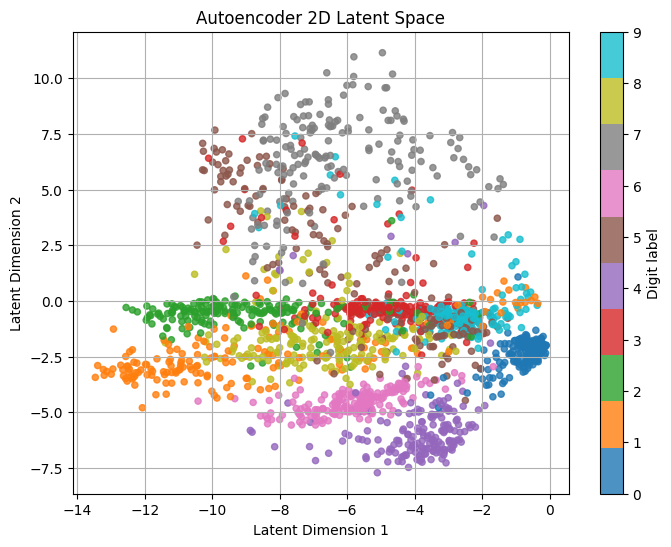

In [25]:
# ============================================================
# Autoencoder 잠재 공간 시각화
# ============================================================

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_autoencoder_2d[:, 0],
    X_autoencoder_2d[:, 1],
    c=y,
    cmap="tab10",
    s=20,
    alpha=0.8
)

plt.colorbar(scatter, label="Digit label")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("Autoencoder 2D Latent Space")
plt.grid(True)
plt.show()

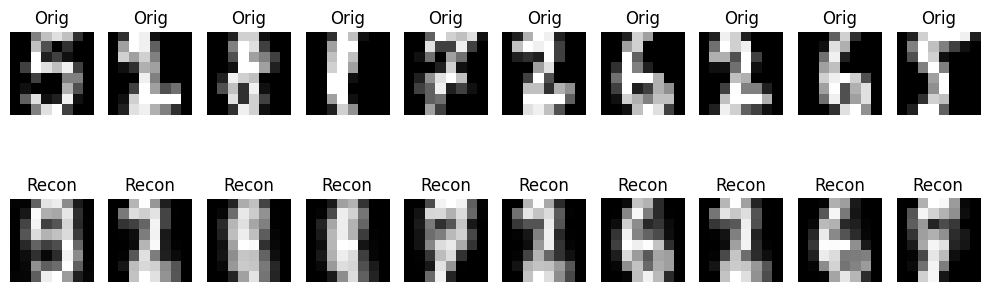

In [26]:
# ============================================================
# 원본 이미지와 복원 이미지 비교
# ============================================================

sample_X = X_test_tensor[:10].to(device)

ae_model.eval()
with torch.no_grad():
    sample_reconstructed, _ = ae_model(sample_X)

sample_original = sample_X.cpu().numpy()
sample_reconstructed = sample_reconstructed.cpu().numpy()

plt.figure(figsize=(10, 4))

for i in range(10):
    # 원본 이미지
    plt.subplot(2, 10, i + 1)
    plt.imshow(sample_original[i].reshape(8, 8), cmap="gray")
    plt.title("Orig")
    plt.axis("off")

    # 복원 이미지
    plt.subplot(2, 10, i + 11)
    plt.imshow(sample_reconstructed[i].reshape(8, 8), cmap="gray")
    plt.title("Recon")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 5. 전체 결과 비교

원본 데이터, PCA, LDA의 분류 정확도를 표와 그래프로 비교합니다. t-SNE, UMAP, Autoencoder 2D는 주로 시각화 목적에 적합합니다.

In [27]:
# ============================================================
# 결과 비교표
# ============================================================

results = pd.DataFrame({
    "Method": ["Original 64D", "PCA 20D", "LDA 9D"],
    "Dimension": [64, 20, 9],
    "Accuracy": [baseline_acc, pca_acc, lda_acc]
})

results["Accuracy"] = results["Accuracy"].round(4)
results

,Method,Dimension,Accuracy
0,Original 64D,64,0.9722
1,PCA 20D,20,0.9417
2,LDA 9D,9,0.9556


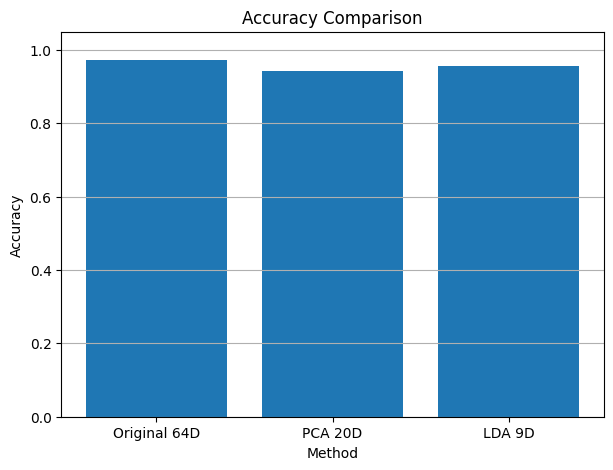

In [28]:
# ============================================================
# 결과 비교 그래프
# ============================================================

plt.figure(figsize=(7, 5))
plt.bar(results["Method"], results["Accuracy"])
plt.ylim(0, 1.05)
plt.xlabel("Method")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.grid(axis="y")
plt.show()

# 6. 실무 해석 기준

## PCA
PCA는 데이터의 분산을 많이 보존하는 방향으로 차원을 줄입니다. 입력 변수가 많고 변수 간 상관관계가 높을 때 유용합니다.

## LDA
LDA는 정답 라벨을 사용하여 클래스가 잘 구분되는 방향으로 차원을 줄입니다. 분류 문제에서 유용합니다.

## t-SNE
고차원 데이터의 가까운 샘플들이 저차원에서도 가깝게 배치되도록 합니다. 주로 군집 시각화에 사용합니다.

## UMAP
t-SNE와 비슷하지만 대체로 빠르고 대용량 데이터에 더 적합합니다.

## Autoencoder
신경망 기반 압축 모델입니다. 이미지 압축, 이상 탐지, 노이즈 제거, 표현 학습에 사용할 수 있습니다.

# 7. 실습 과제

## 과제 1. PCA 주성분 수 변경

다음 값을 변경하면서 정확도를 비교하시오.

```python
n_components = 5
n_components = 10
n_components = 20
n_components = 30
```

## 과제 2. LDA 결과 분석

PCA 2D 시각화와 LDA 2D 시각화를 비교하시오.

## 과제 3. t-SNE 파라미터 변경

```python
perplexity = 5
perplexity = 30
perplexity = 50
```

## 과제 4. UMAP 파라미터 변경

```python
n_neighbors = 5
n_neighbors = 15
n_neighbors = 50
```

## 과제 5. Autoencoder 잠재 차원 변경

Autoencoder의 잠재 차원을 2에서 8로 변경한 뒤 복원 성능을 비교하시오.

```python
nn.Linear(16, 8)
nn.Linear(8, 16)
```

# 7. 실습 과제 코드 완성본

아래 코드는 위에서 학습한 `X_train_scaled`, `X_test_scaled`, `y_train`, `y_test`, `X_scaled_all`, `X_ae`, `train_loader`, `test_loader` 변수를 그대로 사용합니다.

각 과제는 바로 실행할 수 있도록 독립적인 코드 셀로 구성했습니다.

## 과제 1. PCA 주성분 수 변경 후 정확도 비교

`n_components` 값을 5, 10, 20, 30으로 바꾸면서 차원을 줄인 뒤, Logistic Regression 분류 정확도를 비교합니다.

In [ ]:
# ============================================================
# 과제 1. PCA 주성분 수 변경 후 정확도 비교
# ============================================================

# 비교할 PCA 주성분 개수를 리스트로 저장합니다.
# 5는 64차원을 5차원으로 줄인다는 뜻입니다.
# 10은 64차원을 10차원으로 줄인다는 뜻입니다.
# 20은 64차원을 20차원으로 줄인다는 뜻입니다.
# 30은 64차원을 30차원으로 줄인다는 뜻입니다.
pca_components_list = [5, 10, 20, 30]

# 각 PCA 결과를 저장할 빈 리스트를 만듭니다.
pca_task_results = []

# 리스트에 들어 있는 주성분 개수를 하나씩 꺼내서 반복합니다.
for n_components in pca_components_list:

    # PCA 객체를 생성합니다.
    # n_components는 줄이고 싶은 차원의 개수입니다.
    pca = PCA(
        n_components=n_components,
        random_state=SEED
    )

    # 학습 데이터에 PCA를 적용합니다.
    # fit_transform()은 PCA 축을 찾고, 그 축으로 데이터를 변환합니다.
    X_train_pca = pca.fit_transform(X_train_scaled)

    # 테스트 데이터에는 transform()만 사용합니다.
    # 테스트 데이터로 PCA 축을 새로 찾으면 데이터 누수가 발생할 수 있습니다.
    X_test_pca = pca.transform(X_test_scaled)

    # PCA로 줄인 데이터에 사용할 분류 모델을 생성합니다.
    model = LogisticRegression(
        max_iter=2000,
        random_state=SEED
    )

    # PCA가 적용된 학습 데이터로 모델을 학습합니다.
    model.fit(X_train_pca, y_train)

    # PCA가 적용된 테스트 데이터로 예측합니다.
    y_pred = model.predict(X_test_pca)

    # 예측 결과와 실제 정답을 비교하여 정확도를 계산합니다.
    acc = accuracy_score(y_test, y_pred)

    # PCA가 보존한 정보량을 계산합니다.
    # explained_variance_ratio_는 각 주성분이 설명하는 데이터 분산 비율입니다.
    explained_variance = pca.explained_variance_ratio_.sum()

    # 결과를 딕셔너리 형태로 저장합니다.
    pca_task_results.append({
        "PCA 차원 수": n_components,
        "누적 설명 분산 비율": round(explained_variance, 4),
        "분류 정확도": round(acc, 4)
    })

# 리스트를 표 형태의 DataFrame으로 변환합니다.
pca_task_df = pd.DataFrame(pca_task_results)

# 결과표를 출력합니다.
pca_task_df

In [ ]:
# ============================================================
# 과제 1 결과 시각화
# ============================================================

# 그래프 크기를 설정합니다.
plt.figure(figsize=(8, 5))

# x축은 PCA 차원 수, y축은 분류 정확도입니다.
plt.plot(
    pca_task_df["PCA 차원 수"],
    pca_task_df["분류 정확도"],
    marker="o",
    label="Accuracy"
)

# 기준 모델 정확도를 가로선으로 표시합니다.
# 기준 모델은 차원 축소 전 64차원 데이터를 사용한 모델입니다.
plt.axhline(
    y=baseline_acc,
    linestyle="--",
    label="Original 64D Accuracy"
)

plt.xlabel("Number of PCA Components")
plt.ylabel("Accuracy")
plt.title("PCA Components vs Classification Accuracy")
plt.xticks(pca_components_list)
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

print("해석:")
print("- PCA 차원 수가 너무 작으면 정보 손실이 커져 정확도가 낮아질 수 있습니다.")
print("- PCA 차원 수가 커질수록 원본 정보가 더 많이 보존되어 정확도가 좋아지는 경향이 있습니다.")
print("- 단, 차원 수가 너무 커지면 압축 효과는 줄어듭니다.")

## 과제 2. PCA 2D 시각화와 LDA 2D 시각화 비교

PCA는 라벨을 보지 않고 데이터의 분산이 큰 방향을 찾습니다.  
LDA는 라벨을 보고 숫자 클래스가 잘 나뉘는 방향을 찾습니다.

In [ ]:
# ============================================================
# 과제 2. PCA 2D와 LDA 2D 결과를 한 번에 비교
# ============================================================

# PCA 2D 결과는 앞에서 만든 X_train_pca_2d를 사용합니다.
# LDA 2D 결과는 앞에서 만든 X_train_lda_2d를 사용합니다.

# 그래프 전체 크기를 설정합니다.
plt.figure(figsize=(14, 6))

# ------------------------------------------------------------
# 왼쪽 그래프: PCA 2D
# ------------------------------------------------------------
plt.subplot(1, 2, 1)

scatter1 = plt.scatter(
    X_train_pca_2d[:, 0],
    X_train_pca_2d[:, 1],
    c=y_train,
    cmap="tab10",
    s=20,
    alpha=0.8
)

plt.colorbar(scatter1, label="Digit label")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA 2D Visualization")
plt.grid(True)

# ------------------------------------------------------------
# 오른쪽 그래프: LDA 2D
# ------------------------------------------------------------
plt.subplot(1, 2, 2)

scatter2 = plt.scatter(
    X_train_lda_2d[:, 0],
    X_train_lda_2d[:, 1],
    c=y_train,
    cmap="tab10",
    s=20,
    alpha=0.8
)

plt.colorbar(scatter2, label="Digit label")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA 2D Visualization")
plt.grid(True)

plt.tight_layout()
plt.show()

print("비교 해석:")
print("1. PCA는 정답 라벨을 사용하지 않습니다.")
print("   그래서 숫자 종류를 잘 나누는 것보다 데이터의 전체 퍼짐이 큰 방향을 먼저 찾습니다.")
print("2. LDA는 정답 라벨을 사용합니다.")
print("   그래서 숫자 0~9가 서로 잘 구분되는 방향을 찾으려고 합니다.")
print("3. 분류 문제에서는 보통 LDA 2D가 PCA 2D보다 클래스 구분이 더 뚜렷하게 보일 수 있습니다.")
print("4. 하지만 LDA는 반드시 정답 라벨이 있어야 사용할 수 있습니다.")

## 과제 3. t-SNE 파라미터 변경

`perplexity`는 t-SNE가 주변 이웃을 어느 정도 넓게 볼지 정하는 값입니다.  
값이 작으면 아주 가까운 이웃 중심으로 보고, 값이 크면 더 넓은 이웃 관계를 봅니다.

In [ ]:
# ============================================================
# 과제 3. t-SNE perplexity 값 변경 비교
# ============================================================

# 비교할 perplexity 값을 리스트로 저장합니다.
perplexity_list = [5, 30, 50]

# 각 perplexity 값마다 t-SNE를 실행합니다.
for perplexity_value in perplexity_list:

    # t-SNE 객체를 생성합니다.
    # n_components=2는 2차원으로 줄인다는 뜻입니다.
    # perplexity는 주변 이웃을 몇 개 정도 고려할지에 가까운 의미입니다.
    tsne_model = TSNE(
        n_components=2,
        perplexity=perplexity_value,
        learning_rate="auto",
        init="pca",
        random_state=SEED
    )

    # t-SNE는 보통 전체 데이터를 한 번에 넣고 2차원 좌표를 만듭니다.
    X_tsne_result = tsne_model.fit_transform(X_scaled_all)

    # 결과를 시각화합니다.
    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        X_tsne_result[:, 0],
        X_tsne_result[:, 1],
        c=y,
        cmap="tab10",
        s=20,
        alpha=0.8
    )

    plt.colorbar(scatter, label="Digit label")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.title(f"t-SNE 2D Visualization, perplexity={perplexity_value}")
    plt.grid(True)
    plt.show()

print("해석:")
print("- perplexity=5: 가까운 주변 데이터 관계를 강하게 반영합니다. 군집이 더 잘게 나뉘어 보일 수 있습니다.")
print("- perplexity=30: 일반적으로 많이 사용하는 기본적인 수준입니다.")
print("- perplexity=50: 더 넓은 주변 관계를 반영합니다. 전체 구조가 더 부드럽게 보일 수 있습니다.")
print("- t-SNE 결과는 random_state, perplexity, 데이터 스케일에 따라 모양이 달라질 수 있습니다.")

## 과제 4. UMAP 파라미터 변경

`n_neighbors`는 UMAP이 한 점 주변의 이웃을 몇 개까지 고려할지 정하는 값입니다.  
작은 값은 지역 구조, 큰 값은 전체 구조를 더 많이 반영합니다.

In [ ]:
# ============================================================
# 과제 4. UMAP n_neighbors 값 변경 비교
# ============================================================

# 비교할 n_neighbors 값을 리스트로 저장합니다.
neighbors_list = [5, 15, 50]

# 각 n_neighbors 값마다 UMAP을 실행합니다.
for neighbors_value in neighbors_list:

    # UMAP 객체를 생성합니다.
    # n_neighbors는 주변 이웃을 몇 개까지 볼지 정합니다.
    # min_dist는 2차원 공간에서 점들이 얼마나 가까워질 수 있는지 정합니다.
    umap_model_task = umap.UMAP(
        n_components=2,
        n_neighbors=neighbors_value,
        min_dist=0.1,
        random_state=SEED
    )

    # 전체 표준화 데이터를 2차원으로 변환합니다.
    X_umap_result = umap_model_task.fit_transform(X_scaled_all)

    # 결과를 시각화합니다.
    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        X_umap_result[:, 0],
        X_umap_result[:, 1],
        c=y,
        cmap="tab10",
        s=20,
        alpha=0.8
    )

    plt.colorbar(scatter, label="Digit label")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.title(f"UMAP 2D Visualization, n_neighbors={neighbors_value}")
    plt.grid(True)
    plt.show()

print("해석:")
print("- n_neighbors=5: 가까운 데이터끼리의 지역 구조가 강조됩니다.")
print("- n_neighbors=15: 지역 구조와 전체 구조의 균형을 보는 일반적인 설정입니다.")
print("- n_neighbors=50: 더 넓은 범위의 데이터 관계를 반영하여 전체 구조가 강조됩니다.")
print("- UMAP은 t-SNE보다 빠른 경우가 많고, 시각화와 표현 학습에 자주 사용됩니다.")

## 과제 5. Autoencoder 잠재 차원 변경

기존 Autoencoder는 잠재 차원이 2였습니다.  
이번 과제에서는 잠재 차원을 8로 바꾸고, 복원 손실(MSE Loss)을 비교합니다.

In [ ]:
# ============================================================
# 과제 5. 잠재 차원 8 Autoencoder 모델 정의
# ============================================================

class AutoencoderLatent8(nn.Module):
    def __init__(self):
        super(AutoencoderLatent8, self).__init__()

        # Encoder는 64차원 입력을 8차원 잠재 벡터로 압축합니다.
        self.encoder = nn.Sequential(
            nn.Linear(64, 32),   # 64차원 입력을 32차원으로 줄입니다.
            nn.ReLU(),           # 음수는 0으로 만들고, 양수는 그대로 통과시킵니다.
            nn.Linear(32, 16),   # 32차원을 16차원으로 줄입니다.
            nn.ReLU(),
            nn.Linear(16, 8)     # 16차원을 8차원 잠재 벡터로 줄입니다.
        )

        # Decoder는 8차원 잠재 벡터를 다시 64차원 이미지 벡터로 복원합니다.
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),    # 8차원을 16차원으로 늘립니다.
            nn.ReLU(),
            nn.Linear(16, 32),   # 16차원을 32차원으로 늘립니다.
            nn.ReLU(),
            nn.Linear(32, 64),   # 32차원을 원래 입력 크기인 64차원으로 복원합니다.
            nn.Sigmoid()         # 픽셀 값을 0~1 범위로 맞춥니다.
        )

    def forward(self, x):
        # 입력 데이터를 8차원으로 압축합니다.
        z = self.encoder(x)

        # 압축된 8차원 벡터를 다시 64차원으로 복원합니다.
        reconstructed = self.decoder(z)

        return reconstructed, z

# 잠재 차원 8 모델을 생성합니다.
ae_model_8 = AutoencoderLatent8().to(device)

print(ae_model_8)

In [ ]:
# ============================================================
# 과제 5. 잠재 차원 8 Autoencoder 학습 함수 정의
# ============================================================

def train_autoencoder_model(model, train_loader, test_loader, epochs=100, learning_rate=0.001):
    # 손실 함수는 MSELoss를 사용합니다.
    # MSELoss는 원본 이미지와 복원 이미지의 차이를 제곱해서 평균냅니다.
    criterion = nn.MSELoss()

    # Adam 최적화 알고리즘으로 모델 가중치를 업데이트합니다.
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # epoch별 손실을 저장할 리스트입니다.
    train_loss_history = []
    test_loss_history = []

    # 지정한 epoch 수만큼 반복 학습합니다.
    for epoch in range(epochs):

        # 모델을 학습 모드로 바꿉니다.
        model.train()

        # 학습 손실 합계를 저장합니다.
        train_loss_sum = 0.0

        # DataLoader에서 배치 단위로 데이터를 꺼냅니다.
        for batch_X, batch_y in train_loader:

            # 데이터를 CPU 또는 GPU 장치로 보냅니다.
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            # 이전 배치에서 계산된 gradient를 초기화합니다.
            optimizer.zero_grad()

            # 모델이 입력을 복원합니다.
            reconstructed, z = model(batch_X)

            # 복원 결과와 원본 입력의 차이를 손실로 계산합니다.
            loss = criterion(reconstructed, batch_y)

            # 역전파로 각 가중치가 얼마나 수정되어야 하는지 계산합니다.
            loss.backward()

            # 계산된 gradient를 이용해 가중치를 업데이트합니다.
            optimizer.step()

            # 현재 배치 손실을 누적합니다.
            train_loss_sum += loss.item()

        # 배치별 손실 평균을 구합니다.
        train_loss_avg = train_loss_sum / len(train_loader)

        # 모델을 평가 모드로 바꿉니다.
        model.eval()

        # 테스트 손실 합계를 저장합니다.
        test_loss_sum = 0.0

        # 평가에서는 gradient 계산이 필요 없으므로 no_grad()를 사용합니다.
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)

                reconstructed, z = model(batch_X)
                loss = criterion(reconstructed, batch_y)
                test_loss_sum += loss.item()

        # 테스트 손실 평균을 구합니다.
        test_loss_avg = test_loss_sum / len(test_loader)

        # 손실 기록을 저장합니다.
        train_loss_history.append(train_loss_avg)
        test_loss_history.append(test_loss_avg)

        # 10 epoch마다 중간 결과를 출력합니다.
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss_avg:.6f} Test Loss: {test_loss_avg:.6f}")

    return train_loss_history, test_loss_history

# 잠재 차원 8 Autoencoder를 학습합니다.
# 위의 기존 모델과 동일하게 100 epoch를 사용합니다.
train_losses_8, test_losses_8 = train_autoencoder_model(
    model=ae_model_8,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=100,
    learning_rate=0.001
)

In [ ]:
# ============================================================
# 과제 5. 잠재 차원 2와 잠재 차원 8 복원 손실 비교
# ============================================================

# 기존 Autoencoder의 마지막 테스트 손실입니다.
# 앞에서 학습한 test_losses 리스트를 사용합니다.
latent2_final_loss = test_losses[-1]

# 새로 학습한 잠재 차원 8 Autoencoder의 마지막 테스트 손실입니다.
latent8_final_loss = test_losses_8[-1]

# 결과를 표로 정리합니다.
ae_compare_df = pd.DataFrame({
    "Model": ["Autoencoder Latent 2D", "Autoencoder Latent 8D"],
    "Latent Dimension": [2, 8],
    "Final Test MSE Loss": [
        round(latent2_final_loss, 6),
        round(latent8_final_loss, 6)
    ]
})

ae_compare_df

In [ ]:
# ============================================================
# 과제 5. 손실 그래프 비교
# ============================================================

plt.figure(figsize=(8, 5))

# 기존 잠재 차원 2 모델의 테스트 손실 그래프입니다.
plt.plot(
    test_losses,
    label="Latent 2D Test Loss"
)

# 새로 학습한 잠재 차원 8 모델의 테스트 손실 그래프입니다.
plt.plot(
    test_losses_8,
    label="Latent 8D Test Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Reconstruction Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

print("해석:")
print("- MSE Loss는 원본 이미지와 복원 이미지의 차이를 의미합니다.")
print("- 값이 낮을수록 원본 이미지에 더 가깝게 복원한 것입니다.")
print("- 잠재 차원 8은 잠재 차원 2보다 더 많은 정보를 저장할 수 있습니다.")
print("- 따라서 일반적으로 잠재 차원 8 모델의 복원 손실이 더 낮게 나올 가능성이 큽니다.")

In [ ]:
# ============================================================
# 과제 5. 잠재 차원 8 모델의 원본 이미지와 복원 이미지 비교
# ============================================================

# 테스트 데이터에서 앞의 10개 샘플을 가져옵니다.
sample_X = X_test_tensor[:10].to(device)

# 모델을 평가 모드로 변경합니다.
ae_model_8.eval()

# 복원 이미지를 생성합니다.
with torch.no_grad():
    sample_reconstructed_8, _ = ae_model_8(sample_X)

# Tensor를 numpy 배열로 변환합니다.
sample_original = sample_X.cpu().numpy()
sample_reconstructed_8 = sample_reconstructed_8.cpu().numpy()

# 그래프 크기를 설정합니다.
plt.figure(figsize=(10, 4))

# 원본 이미지 10개와 복원 이미지 10개를 비교합니다.
for i in range(10):

    # 첫 번째 줄: 원본 이미지
    plt.subplot(2, 10, i + 1)
    plt.imshow(sample_original[i].reshape(8, 8), cmap="gray")
    plt.title("Orig")
    plt.axis("off")

    # 두 번째 줄: 잠재 차원 8 모델이 복원한 이미지
    plt.subplot(2, 10, i + 11)
    plt.imshow(sample_reconstructed_8[i].reshape(8, 8), cmap="gray")
    plt.title("Recon")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 8. 실습 과제 최종 정리

## 과제 1 정리
PCA 주성분 수를 5, 10, 20, 30으로 늘리면 일반적으로 보존되는 정보량이 증가합니다.  
정보량이 증가하면 분류 정확도도 좋아지는 경향이 있지만, 차원 축소 효과는 줄어듭니다.

## 과제 2 정리
PCA는 라벨을 사용하지 않고 데이터의 분산 방향을 찾습니다.  
LDA는 라벨을 사용하여 클래스가 잘 구분되는 방향을 찾습니다.  
따라서 숫자 분류 문제에서는 LDA 시각화가 PCA보다 클래스 구분이 더 뚜렷하게 보일 수 있습니다.

## 과제 3 정리
t-SNE의 `perplexity`가 작으면 가까운 점들 중심의 지역 구조가 강조됩니다.  
값이 커지면 더 넓은 범위의 관계가 반영됩니다.

## 과제 4 정리
UMAP의 `n_neighbors`가 작으면 지역 구조가 강조됩니다.  
값이 커지면 전체 구조가 더 많이 반영됩니다.

## 과제 5 정리
Autoencoder의 잠재 차원을 2에서 8로 늘리면 압축 공간이 넓어집니다.  
더 많은 정보를 저장할 수 있으므로 일반적으로 복원 손실이 낮아질 가능성이 큽니다.